Feature Engineering

In [5]:
import numpy as np
import pandas as pd

In [6]:
df=pd.read_csv(r'anime.csv')
df.head()

,Rank,Title,Score
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05


In [7]:
df.iloc[2]['Title']

'Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members'

In [8]:
def extract_episode(txt):
  check=False
  data=''
  for i in txt:
      if i==')':
        check=False
        return data

      if check==True:
       data+=i

      if i=='(':
        check=True

In [9]:
df['Episode']=df['Title'].apply(extract_episode)
df.head()

,Rank,Title,Score,Episode
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64 eps
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24 eps
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13 eps
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51 eps
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10 eps


In [10]:
df['Episode']=df['Episode'].str.replace(" eps","")
df.head()

,Rank,Title,Score,Episode
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10


In [11]:
df['Episode']=df['Episode'].astype(int)
df.head()

,Rank,Title,Score,Episode
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10


In [12]:
def extract_time(txt):
  check=False
  data=""
  for i in range (len(txt)):
    if txt[i]==')':
      for j in range (i+1,i+20):
        data+=txt[j]
      return data


In [13]:
df['Total Time']=df['Title'].apply(extract_time)
df.head()

,Rank,Title,Score,Episode,Total Time
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019


In [14]:
from dateutil.relativedelta import relativedelta
from datetime import datetime

def calculate_total_months(period):
    try:
        start_str, end_str = period.split(' - ')
        start_date = datetime.strptime(start_str, '%b %Y')
        end_date = datetime.strptime(end_str, '%b %Y')
        r = relativedelta(end_date, start_date)
        return r.years * 12 + r.months + 1  # +1 to include the starting month
    except:
        return None

df['Months'] = df['Total Time'].apply(calculate_total_months)
df.head()

,Rank,Title,Score,Episode,Total Time,Months
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010,16
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011,6
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022,3
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016,12
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019,4


In [15]:
df[df['Score']==df['Score'].max()]['Title']

,Title
0,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...


In [16]:
df['Title'].head()

,Title
0,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...
1,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473..."
2,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...
3,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ..."
4,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...


In [17]:
df[df['Episode']==df['Episode'].max()]

,Rank,Title,Score,Episode,Total Time,Months
15,16,"GintamaTV (201 eps)Apr 2006 - Mar 20101,034,41...",8.94,201,Apr 2006 - Mar 2010,48


In [18]:
df[df['Months']==df['Months'].max()]

,Rank,Title,Score,Episode,Total Time,Months
11,12,Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Ma...,9.02,110,Jan 1988 - Mar 1997,111


In [19]:
df.sort_values(by='Episode', ascending=False).head(5)[['Title', 'Episode']]

,Title,Episode
15,"GintamaTV (201 eps)Apr 2006 - Mar 20101,034,41...",201
7,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,148
11,Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Ma...,110
42,Hajime no IppoTV (75 eps)Oct 2000 - Mar 200255...,75
24,"MonsterTV (74 eps)Apr 2004 - Sep 20051,041,081...",74


In [20]:
df['Episodes_Per_Month'] = df['Episode'] / df['Months']
df['Episodes_Per_Year'] = df['Episodes_Per_Month'] * 12
df.sort_values(by='Episodes_Per_Year', ascending=False).head(1)[['Title', 'Episodes_Per_Year']]

,Title,Episodes_Per_Year
30,Jujutsu Kaisen 2nd SeasonTV (23 eps)Jul 2023 -...,138.0


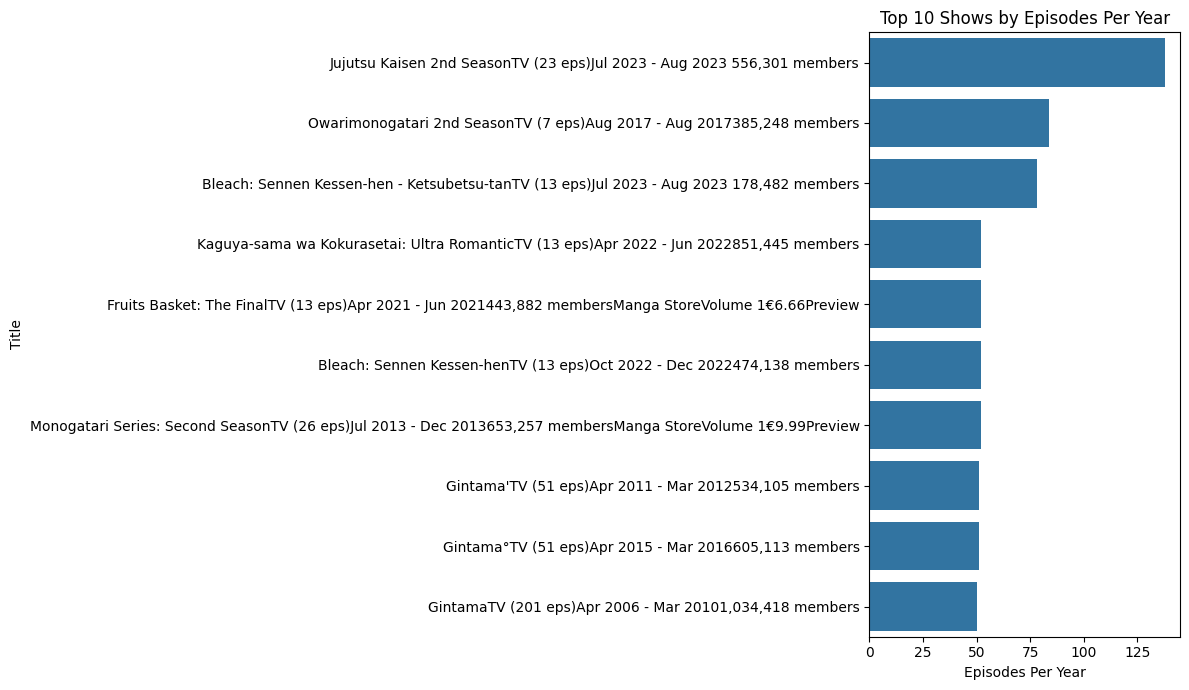

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10_episodes_per_year = df.sort_values(by='Episodes_Per_Year', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Episodes_Per_Year', y='Title', data=top_10_episodes_per_year)
plt.title('Top 10 Shows by Episodes Per Year')
plt.xlabel('Episodes Per Year')
plt.ylabel('Title')
plt.tight_layout()
plt.show()